In [1]:
import os
import yaml
import logging
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
from sklearn.metrics import precision_recall_curve, classification_report

from pyspark.sql.functions import col, udf
from pyspark.sql.types import FloatType
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import GBTClassificationModel

from utils.spark_session import get_spark_session

from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.metrics import f1_score, classification_report

spark = get_spark_session("08-evaluate-pipeline-artifacts")

In [2]:
test_path = os.path.join("..", "data", "train_test", "test.parquet")
config_path = os.path.join("..", "src", "config", "feature_config.yaml")
features_selected_path = os.path.join("..", "src", "features", "selected", "features_selected.yaml")
model_path = os.path.join("..", "models", "final_gbt_model")

In [3]:
# Load files
df = spark.read.parquet(test_path)
with open(config_path, 'r') as f:
    feature_config = yaml.safe_load(f)
with open(features_selected_path, 'r') as f:
    selected_yaml = yaml.safe_load(f)


In [4]:
# Define target and features
target_col = [k for k, v in feature_config.items() if isinstance(v, dict) and v.get("target")][0]
selected_features = selected_yaml.get("support_random_forest", [])
available_cols = [f.name for f in df.schema.fields]
feature_cols = [f for f in selected_features if f in available_cols]

In [5]:
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_test = assembler.transform(df.select(*(feature_cols + [target_col]))).select("features", col(target_col).alias("label"))

df_test.show()

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[3.13043478260869...|    0|
|[1.36956521739130...|    0|
|[8.54347826086956...|    0|
|[1.82903225806451...|    0|
|[1.12580645161290...|    0|
|[0.006,0.006,186....|    0|
|[1.45806451612903...|    0|
|[3.00000000000000...|    0|
|[2.09032258064516...|    0|
|[2.76774193548387...|    0|
|[2.39354838709677...|    0|
|[1.92682926829268...|    0|
|[1.04878048780487...|    0|
|[3.43902439024390...|    0|
|[2.69268292682926...|    1|
|[2.26829268292682...|    0|
|[3.53658536585365...|    0|
|[3.65853658536585...|    0|
|[4.53658536585365...|    0|
|[4.63414634146341...|    0|
+--------------------+-----+
only showing top 20 rows



In [6]:
# Load model and fit model

model = GBTClassificationModel.load(model_path)
predictions = model.transform(df_test)

In [7]:
extract_prob_1 = udf(lambda v: float(v[1]), FloatType())
predictions = predictions.withColumn("prob_1", extract_prob_1(col("probability")))

In [8]:
pred_pd = predictions.select("prob_1", "prediction", "label").toPandas()
probs = pred_pd["prob_1"].values
true_labels = pred_pd["label"].values

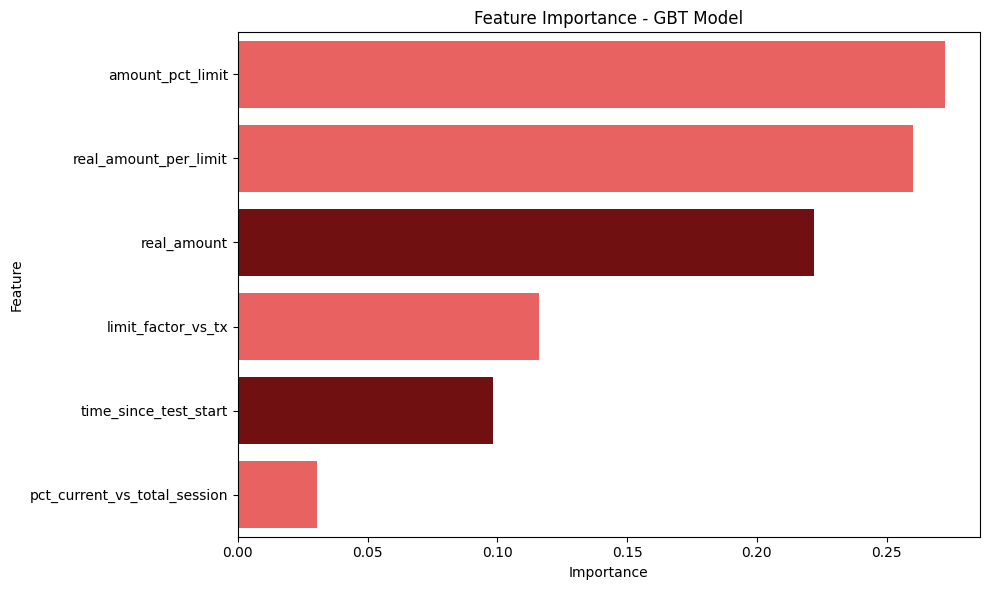

In [9]:
# Load trained model and extract importances
importances = model.featureImportances.toArray()
final_features = selected_features[:len(importances)]

# Assemble features for test set
assembler = VectorAssembler(inputCols=final_features, outputCol="features")
df_test = assembler.transform(df.select(*(final_features + [target_col])))
df_test = df_test.select("features", col(target_col).alias("label"))

# Define engineered features manually based on your YAML
engineered_features = [
    'real_amount_per_limit',
    'n_transactions_so_far',
    'amount_cumulative',
    'n_conversions_so_far',
    'pct_current_vs_total_session',
    'amount_pct_limit',
    'limit_factor_vs_tx'
]

# Build importance DataFrame
feature_importance_df = pd.DataFrame({
    'feature': final_features,
    'importance': importances
})

# Filter out zero-importance features
feature_importance_df = feature_importance_df[feature_importance_df['importance'] > 0]

# Assign color by type
feature_importance_df['color'] = feature_importance_df['feature'].apply(
    lambda x: '#ff4c4c' if x in engineered_features else '#800000'  # light red vs dark red
)

# Sort
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance_df,
    palette=feature_importance_df['color'].tolist()
)
plt.title('Feature Importance - GBT Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [10]:
# Calculate total importance of engineered vs original features
engineered_total = feature_importance_df[
    feature_importance_df['feature'].isin(engineered_features)
]['importance'].sum()

overall_total = feature_importance_df['importance'].sum()

engineered_percentage = engineered_total / overall_total * 100
print(f"Engineered features account for {engineered_percentage:.2f}% of total importance.")


Engineered features account for 67.94% of total importance.


In [11]:
pred_pd['score'] = (pred_pd['prob_1'] * 1000).astype(int)

# Add a ranking with tie-breaking for repeated values
pred_pd['rank_score'] = pred_pd['score'].rank(method='first')

# Apply qcut on the ranking — this always works
pred_pd['decil'] = pd.qcut(pred_pd['rank_score'], q=10, labels=False)

# Calculate the proportion of positives per decile
results = (
    pred_pd.groupby('decil').label.sum() / pred_pd.label.sum()
).reset_index()

# Adjust decile display to range from 1 to 10
results['decil'] += 1

# Count positive offers and total items per decile
results['offers'] = pred_pd[pred_pd.label == 1].groupby('decil').size()
results['total_items'] = pred_pd.groupby('decil').size().astype(int)
results['no_offers'] = results['total_items'] - results['offers']
results['score (>=)'] = round(pred_pd.groupby('decil').score.min(), 3)

# Handle any missing values
results.fillna(0, inplace=True)

# Sort by descending decile
results.sort_values(by='decil', ascending=False, inplace=True)

# Reorganize columns and rename 'label' to 'recall'
results = results[['decil', 'score (>=)', 'offers', 'no_offers', 'total_items', 'label']]
results = results.rename(columns={'label': 'recall'})

# Calculate cumulative recall and precision
results['recall'] = results['recall'].cumsum()
results['precision'] = results['offers'] / results['total_items']

# Calculate cumulative non-offers and total items
results['no_offers'] = results['no_offers'].cumsum()
results['total_items'] = results['total_items'].cumsum()

# Reset index
results.reset_index(drop=True, inplace=True)

results


,decil,score (>=),offers,no_offers,total_items,recall,precision
0,10,700,877,1891,2768,0.144815,0.316835
1,9,416,902,3756,5535,0.293758,0.325985
2,8,281,273,6250,8302,0.338838,0.098663
3,7,203,966,8051,11069,0.498349,0.349115
4,6,143,813,10005,13836,0.632596,0.293820
5,5,115,617,12156,16604,0.734478,0.222905
6,4,74,971,13952,19371,0.894815,0.350922
7,3,11,618,16101,22138,0.996863,0.223347
8,2,10,10,18858,24905,0.998514,0.003614
9,1,5,9,21617,27673,1.000000,0.003251


Esta tabela mostra a performance do modelo ao segmentar clientes em 10 decis com base em um score preditivo, onde **Decil 10 representa os clientes com maior score (maior probabilidade de conversão)**.

* **Decis superiores** concentram os clientes com maior chance de conversão, apresentando **maior precisão**. No entanto, o **recall acumulado** ainda é relativamente baixo devido ao menor volume de clientes nesses grupos.

* **Decis inferiores** abrangem a maior parte da base de clientes e garantem **alto recall acumulado**, mas com **baixa precisão**, indicando que, embora o modelo consiga capturar praticamente todos os casos positivos, isso ocorre com muito ruído nessas faixas.

Dessa forma, **ações de marketing devem priorizar os decis superiores**, onde as taxas de conversão são mais favoráveis.


In [12]:
results["recall"]

0    0.144815
1    0.293758
2    0.338838
3    0.498349
4    0.632596
5    0.734478
6    0.894815
7    0.996863
8    0.998514
9    1.000000
Name: recall, dtype: float64

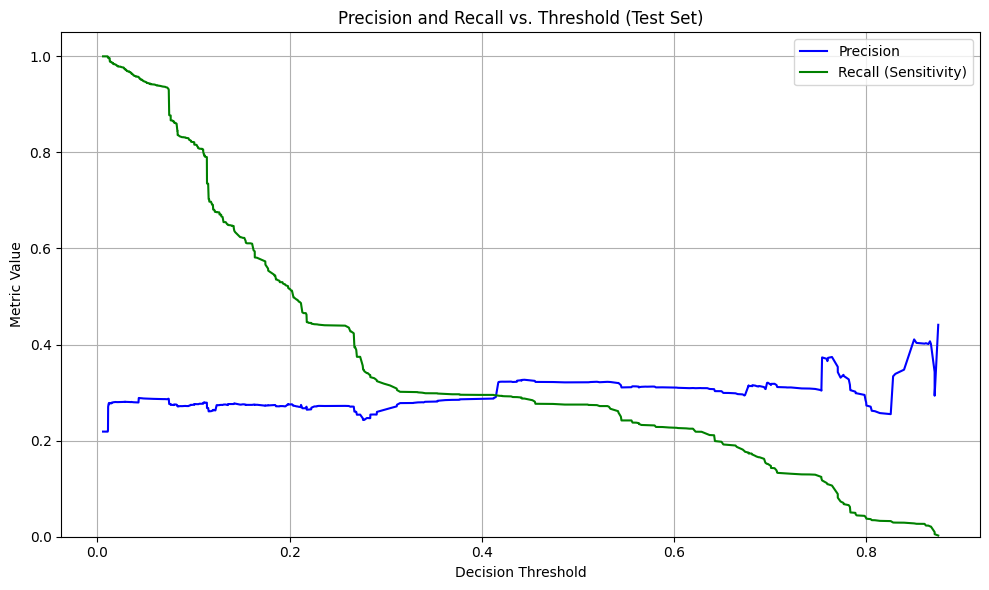

In [13]:
precision, recall, thresholds = precision_recall_curve(true_labels, probs)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall (Sensitivity)', color='green')
plt.xlabel('Decision Threshold')
plt.ylabel('Metric Value')
plt.title('Precision and Recall vs. Threshold (Test Set)')
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

O gráfico mostra como a precisão e a sensibilidade mudam de acordo com o valor de corte (threshold) usado pelo modelo.

* threshold baixo: o modelo classifica quase tudo como positivo. Isso faz com que a sensibilidade seja alta (encontra quase todos os casos positivos), mas a precisão seja baixa (muitos alsos positivos).

* threshold alto: o modelo só classifica como positivo quando está muito confiante. Isso faz com que a precisão aumente, mas a sensibilidade caia bastante, ou seja, ele deixa de identificar muitos casos positivos.

No contexto dos dados, como a oferta envolve um pequeno valor (até R$10), é interessante priorizar a sensibilidade, oferecendo ofertas dentro de uma margem de orçamento disponível. Por outro lado, para ofertas de valores maiores, é importante priorizar a precisão.


In [14]:
#  Compute F1-score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Best threshold based on F1-score: {best_threshold:.4f}")

#  Create new binary predictions based on the best threshold
pred_pd["prediction_thresholded"] = (pred_pd["prob_1"] >= best_threshold).astype(int)

# Generate a new classification report using the adjusted predictions
report_thresh = classification_report(
    y_true=pred_pd["label"],
    y_pred=pred_pd["prediction_thresholded"],
    digits=4
)

print("Classification Report using best threshold (based on F1-score):")
print(report_thresh)


Best threshold based on F1-score: 0.0429
Classification Report using best threshold (based on F1-score):
              precision    recall  f1-score   support

           0     0.9655    0.3401    0.5031     21617
           1     0.2888    0.9566    0.4437      6056

    accuracy                         0.4750     27673
   macro avg     0.6271    0.6484    0.4734     27673
weighted avg     0.8174    0.4750    0.4901     27673



O melhor threshold é 0.07, ideal para dados desbalanceados por equilibrar sensibilidade e precisão. O modelo tem boa acurácia (76,8%) e identifica bem quem aceita a oferta (71,8% de sensibilidade), embora com muitos falsos positivos (47,9% de precisão).

In [15]:
spark.stop()